# EPG4001 — Aprendizaje Supervisado  
# Laboratorio 2

**Pontificia Universidad Católica de Chile**  
**Curso:** EPG4001 — Aprendizaje Supervisado  
**Participantes:** Elvis Rodriguez y Adaney Caro


# Librerías y funciones auxiliares

In [1]:

library(ISLR)
library(MASS)
library(pROC)
library(caret)
library(tidyverse)
library(knitr)
library(e1071)
library(rpart)
library(rpart.plot)
library(randomForest)
library(ROSE)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Loading required package: lattice

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘random

## Función para evaluar clasificadores

La función recibe probabilidades predichas, aplica punto de corte 0.5 y calcula matriz de confusión, Accuracy, Sensibilidad, Especificidad, Precisión, F1-score, Balanced Accuracy y AUC.

In [2]:
evaluar_clasificador <- function(prob, y_obs, positive, nombre, cutoff = 0.5) {

  y_obs <- factor(y_obs)
  negative <- setdiff(levels(y_obs), positive)[1]

  y_pred <- factor(
    ifelse(prob >= cutoff, positive, negative),
    levels = levels(y_obs)
  )

  cm <- caret::confusionMatrix(
    data = y_pred,
    reference = y_obs,
    positive = positive
  )

  VP <- cm$table[positive, positive]
  FP <- cm$table[positive, negative]
  FN <- cm$table[negative, positive]

  roc_obj <- pROC::roc(
    response = as.numeric(y_obs == positive),
    predictor = as.numeric(prob),
    quiet = TRUE
  )

  metricas <- data.frame(
    Modelo = nombre,
    Accuracy = round(as.numeric(cm$overall["Accuracy"]), 4),
    Sensibilidad = round(as.numeric(cm$byClass["Sensitivity"]), 4),
    Especificidad = round(as.numeric(cm$byClass["Specificity"]), 4),
    Precision = round(as.numeric(cm$byClass["Pos Pred Value"]), 4),
    F1 = round(as.numeric(2 * VP / (2 * VP + FP + FN)), 4),
    BalancedAccuracy = round(
      mean(c(
        as.numeric(cm$byClass["Sensitivity"]),
        as.numeric(cm$byClass["Specificity"])
      )),
      4
    ),
    AUC = round(as.numeric(pROC::auc(roc_obj)), 4)
  )

  return(list(
    pred = y_pred,
    cm = cm,
    metricas = metricas,
    roc = roc_obj
  ))
}

# Problema 1 — Base `Default`

Usamos `Default` de la librería `ISLR`. La variable respuesta es `default` y los predictores son `student`, `balance` e `income`.



La variable respuesta es:

$$
default \in \{No, Yes\}
$$

Los predictores disponibles son:

- `student`
- `balance`
- `income`

Se divide la muestra en 70 % entrenamiento y 30 % prueba.

In [3]:
data(Default, package = "ISLR")

Default_p1 <- Default
Default_p1$default <- factor(Default_p1$default, levels = c("No", "Yes"))
Default_p1$student <- factor(Default_p1$student, levels = c("No", "Yes"))
Default_p1$student_bin <- ifelse(Default_p1$student == "Yes", 1, 0)

set.seed(123)

n_p1 <- nrow(Default_p1)
idx_train_p1 <- sample(1:n_p1, size = floor(0.70 * n_p1))

train_p1 <- Default_p1[idx_train_p1, ]
test_p1  <- Default_p1[-idx_train_p1, ]

dim(train_p1)
dim(test_p1)

table(train_p1$default)
prop.table(table(train_p1$default))

[1] 7000    5

[1] 3000    5


  No  Yes 
6767  233 


        No        Yes 
0.96671429 0.03328571 

## 1.a Regresión Logística

Ajustamos una Regresión Logística con `student`, `balance` e `income`.

El modelo es:

$$
\log\left(\frac{P(default=Yes \mid x)}{P(default=No \mid x)}\right)
=
\beta_0+\beta_1student+\beta_2balance+\beta_3income
$$

Luego interpretamos `balance` mediante odds ratio.

In [4]:
mod_logit_p1 <- glm(
  default ~ student + balance + income,
  data = train_p1,
  family = binomial(link = "logit")
)

summary(mod_logit_p1)

tabla_coef_logit_p1 <- summary(mod_logit_p1)$coefficients
tabla_coef_logit_p1


Call:
glm(formula = default ~ student + balance + income, family = binomial(link = "logit"), 
    data = train_p1)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.109e+01  5.923e-01 -18.723   <2e-16 ***
studentYes  -5.222e-01  2.828e-01  -1.847   0.0648 .  
balance      5.760e-03  2.772e-04  20.777   <2e-16 ***
income       7.592e-06  9.799e-06   0.775   0.4385    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2043.8  on 6999  degrees of freedom
Residual deviance: 1094.9  on 6996  degrees of freedom
AIC: 1102.9

Number of Fisher Scoring iterations: 8


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-1.108895e+01,5.922752e-01,-18.722634,3.237372e-78
studentYes,-5.221665e-01,2.827585e-01,-1.846687,6.479252e-02
balance,5.759887e-03,2.772265e-04,20.776828,7.014291e-96
income,7.591530e-06,9.799202e-06,0.774709,4.385116e-01


In [5]:
beta_balance_p1 <- coef(mod_logit_p1)["balance"]

OR_balance_1 <- exp(beta_balance_p1)
OR_balance_100 <- exp(100 * beta_balance_p1)

OR_balance_1
OR_balance_100

cat(
  paste0(
    "Comentario 1.a:\n",
    "Nosotros estimamos un coeficiente para balance igual a ",
    round(beta_balance_p1, 6), ".\n",
    "El odds ratio por una unidad adicional de balance es ",
    round(OR_balance_1, 4), ". Esto significa que, manteniendo constantes student e income, ",
    "cada unidad adicional de balance multiplica los odds de default por ",
    round(OR_balance_1, 4), ".\n",
    "Como una unidad de balance es pequeña, también interpretamos un aumento de 100 unidades: ",
    "el odds ratio es ", round(OR_balance_100, 4), ". Por tanto, un aumento de 100 unidades en balance ",
    "multiplica los odds de default aproximadamente por ", round(OR_balance_100, 4), ".\n",
    "El p-value de balance es ",
    format.pval(tabla_coef_logit_p1["balance", "Pr(>|z|)"], digits = 4),
    ", por lo que balance resulta estadísticamente significativo al 5%.\n"
  )
)

balance 
1.005777

balance 
1.778888

Comentario 1.a:
Nosotros estimamos un coeficiente para balance igual a 0.00576.
El odds ratio por una unidad adicional de balance es 1.0058. Esto significa que, manteniendo constantes student e income, cada unidad adicional de balance multiplica los odds de default por 1.0058.
Como una unidad de balance es pequeña, también interpretamos un aumento de 100 unidades: el odds ratio es 1.7789. Por tanto, un aumento de 100 unidades en balance multiplica los odds de default aproximadamente por 1.7789.
El p-value de balance es < 2.2e-16, por lo que balance resulta estadísticamente significativo al 5%.


### Respuesta para 1.a

La respuesta se basa en el coeficiente estimado de `balance`, su p-value y los odds ratio impresos en la celda anterior.  
Nosotros concluimos que `balance` tiene un efecto positivo sobre los odds de default si su coeficiente es positivo y su odds ratio es mayor que 1. La interpretación con `OR_balance_100` es la más clara, porque expresa el cambio en los odds ante un aumento de 100 unidades de saldo.

## 1.b LDA y QDA

Ajustamos LDA y QDA sobre el mismo conjunto de entrenamiento y con los mismos predictores.

LDA asume una matriz común de covarianzas:

$$
X \mid G=k \sim N(\mu_k,\Sigma)
$$

QDA permite una matriz de covarianzas distinta por clase:

$$
X \mid G=k \sim N(\mu_k,\Sigma_k)
$$

Por eso, QDA puede superar a LDA cuando las clases tienen estructuras de dispersión y correlación diferentes; pero también puede ser menos estable si una clase tiene pocas observaciones.

In [6]:
mod_lda_p1 <- MASS::lda(
  default ~ student_bin + balance + income,
  data = train_p1
)

mod_qda_p1 <- MASS::qda(
  default ~ student_bin + balance + income,
  data = train_p1
)

mod_lda_p1
mod_qda_p1

Call:
lda(default ~ student_bin + balance + income, data = train_p1)

Prior probabilities of groups:
        No        Yes 
0.96671429 0.03328571 

Group means:
    student_bin   balance   income
No    0.2883109  806.0212 33561.71
Yes   0.3733906 1747.6158 32574.86

Coefficients of linear discriminants:
                      LD1
student_bin -1.502378e-01
balance      2.253920e-03
income       5.270439e-06

Call:
qda(default ~ student_bin + balance + income, data = train_p1)

Prior probabilities of groups:
        No        Yes 
0.96671429 0.03328571 

Group means:
    student_bin   balance   income
No    0.2883109  806.0212 33561.71
Yes   0.3733906 1747.6158 32574.86

In [7]:
X_no_p1 <- train_p1[train_p1$default == "No", c("student_bin", "balance", "income")]
X_yes_p1 <- train_p1[train_p1$default == "Yes", c("student_bin", "balance", "income")]

cov_no_p1 <- cov(X_no_p1)
cov_yes_p1 <- cov(X_yes_p1)

cov_no_p1
cov_yes_p1

n_no_p1 <- nrow(X_no_p1)
n_yes_p1 <- nrow(X_yes_p1)

dif_cov_p1 <- sqrt(sum((cov_no_p1 - cov_yes_p1)^2))

n_no_p1
n_yes_p1
dif_cov_p1

cat(
  paste0(
    "Comentario 1.b:\n",
    "Nosotros ajustamos LDA y QDA con los mismos predictores y comparamos sus supuestos.\n",
    "LDA supone una única matriz de covarianzas común para las clases No y Yes; QDA permite una matriz distinta por clase.\n",
    "En nuestros resultados, la matriz de covarianzas de la clase No y la matriz de la clase Yes no son iguales. ",
    "La diferencia global entre ambas matrices, medida con norma de Frobenius, es ",
    round(dif_cov_p1, 4), ".\n",
    "Esto indica que el supuesto de covarianza común de LDA no se cumple exactamente.\n",
    "Por ese motivo, en términos teóricos, esperaríamos que QDA pueda superar a LDA cuando esas diferencias de dispersión ",
    "y correlación entre student_bin, balance e income sean relevantes para separar defaults de no defaults.\n",
    "Sin embargo, en el entrenamiento tenemos ", n_no_p1, " observaciones No y solo ", n_yes_p1, " observaciones Yes. ",
    "Como la clase Yes es pequeña, QDA debe estimar una covarianza propia con poca información relativa, ",
    "por lo que puede ganar flexibilidad pero también perder estabilidad.\n",
    "Entonces, para este conjunto de datos, nuestra respuesta es: QDA sería preferible si la diferencia entre covarianzas ",
    "compensa el mayor riesgo de varianza; si no, LDA es más estable por usar una covarianza común y menos parámetros.\n"
  )
)

,student_bin,balance,income
student_bin,0.2052181,42.67676,-4524.161
balance,42.6767617,206479.58921,-935622.964
income,-4524.1613171,-935622.96411,175840166.114


,student_bin,balance,income
student_bin,0.2349785,32.10949,-5353.594
balance,32.1094931,116843.46038,-576967.439
income,-5353.5936153,-576967.43911,189932259.609


[1] 6767

[1] 233

[1] 14101504

Comentario 1.b:
Nosotros ajustamos LDA y QDA con los mismos predictores y comparamos sus supuestos.
LDA supone una única matriz de covarianzas común para las clases No y Yes; QDA permite una matriz distinta por clase.
En nuestros resultados, la matriz de covarianzas de la clase No y la matriz de la clase Yes no son iguales. La diferencia global entre ambas matrices, medida con norma de Frobenius, es 14101503.5606.
Esto indica que el supuesto de covarianza común de LDA no se cumple exactamente.
Por ese motivo, en términos teóricos, esperaríamos que QDA pueda superar a LDA cuando esas diferencias de dispersión y correlación entre student_bin, balance e income sean relevantes para separar defaults de no defaults.
Sin embargo, en el entrenamiento tenemos 6767 observaciones No y solo 233 observaciones Yes. Como la clase Yes es pequeña, QDA debe estimar una covarianza propia con poca información relativa, por lo que puede ganar flexibilidad pero también perder estabilidad.
Entonces, para est

### Respuesta para 1.b

Nosotros esperaríamos que QDA supere a LDA cuando las clases `No` y `Yes` presenten matrices de covarianzas claramente distintas, porque QDA permite que cada clase tenga su propia estructura de varianzas y correlaciones. En cambio, LDA impone una covarianza común y por eso genera una frontera lineal más restrictiva.

En los resultados observamos que las matrices de covarianzas no son iguales, por lo que el supuesto de LDA no se cumple exactamente. Sin embargo, la clase `Yes` tiene muchas menos observaciones que la clase `No`, lo que puede hacer que QDA sea menos estable. Por tanto, nuestra interpretación es que QDA tiene justificación teórica si las diferencias de covarianza son importantes para clasificar, pero en esta base debe evaluarse con cautela por el desbalance de clases.

## 1.c Naive Bayes

Naive Bayes asume independencia condicional de los predictores dado el grupo:

$$
f_k(x)=\prod_{j=1}^{p} f_{kj}(x_j)
$$

Evaluamos si este supuesto es razonable revisando la correlación entre `balance` e `income`, tanto en la muestra total como dentro de cada clase.

In [8]:
cor_total_p1 <- cor(train_p1$balance, train_p1$income)

cor_no_p1 <- cor(
  train_p1$balance[train_p1$default == "No"],
  train_p1$income[train_p1$default == "No"]
)

cor_yes_p1 <- cor(
  train_p1$balance[train_p1$default == "Yes"],
  train_p1$income[train_p1$default == "Yes"]
)

cor_total_p1
cor_no_p1
cor_yes_p1

mod_nb_p1 <- e1071::naiveBayes(
  default ~ student + balance + income,
  data = train_p1
)

mod_nb_p1

cat(
  paste0(
    "Comentario 1.c:\n",
    "Naive Bayes asume independencia condicional: dado el valor de default, los predictores se consideran independientes entre sí.\n",
    "Para evaluar ese supuesto en balance e income, calculamos sus correlaciones.\n",
    "La correlación total entre balance e income es ", round(cor_total_p1, 4), ".\n",
    "Dentro de la clase No, la correlación es ", round(cor_no_p1, 4), ".\n",
    "Dentro de la clase Yes, la correlación es ", round(cor_yes_p1, 4), ".\n",
    "Estas correlaciones son negativas y de magnitud baja a moderada. Por lo tanto, el supuesto de independencia condicional ",
    "no se cumple de manera perfecta, porque balance e income no son completamente independientes dentro de cada clase.\n",
    "Sin embargo, la relación observada no parece extremadamente fuerte. Por eso, para este conjunto de datos, nosotros consideramos ",
    "que el supuesto es una aproximación razonable pero simplificadora: no es exacto, aunque tampoco se observa una dependencia tan alta ",
    "entre balance e income como para invalidar automáticamente el uso de Naive Bayes.\n"
  )
)

[1] -0.149082

[1] -0.1552756

[1] -0.1224756


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
        No        Yes 
0.96671429 0.03328571 

Conditional probabilities:
     student
Y            No       Yes
  No  0.7116891 0.2883109
  Yes 0.6266094 0.3733906

     balance
Y          [,1]     [,2]
  No   806.0212 454.4003
  Yes 1747.6158 341.8237

     income
Y         [,1]     [,2]
  No  33561.71 13260.47
  Yes 32574.86 13781.59


Comentario 1.c:
Naive Bayes asume independencia condicional: dado el valor de default, los predictores se consideran independientes entre sí.
Para evaluar ese supuesto en balance e income, calculamos sus correlaciones.
La correlación total entre balance e income es -0.1491.
Dentro de la clase No, la correlación es -0.1553.
Dentro de la clase Yes, la correlación es -0.1225.
Estas correlaciones son negativas y de magnitud baja a moderada. Por lo tanto, el supuesto de independencia condicional no se cumple de manera perfecta, porque balance e income no son completamente independientes dentro de cada clase.
Sin embargo, la relación observada no parece extremadamente fuerte. Por eso, para este conjunto de datos, nosotros consideramos que el supuesto es una aproximación razonable pero simplificadora: no es exacto, aunque tampoco se observa una dependencia tan alta entre balance e income como para invalidar automáticamente el uso de Naive Bayes.


### Respuesta para 1.c

El supuesto de Naive Bayes es que, condicionado en la clase `default`, los predictores son independientes. En este caso revisamos específicamente la relación entre `balance` e `income`.

Con las correlaciones impresas, observamos una relación negativa de baja a moderada tanto en la muestra total como dentro de cada clase. Por ello, nosotros concluimos que el supuesto de independencia condicional **no se cumple exactamente**, pero puede considerarse una **aproximación razonable** para este conjunto de datos, porque la dependencia entre `balance` e `income` no parece suficientemente alta como para descartar el modelo por ese motivo.

## 1.d Evaluación de los cuatro clasificadores

Evaluamos Regresión Logística, LDA, QDA y Naive Bayes sobre el conjunto de prueba usando punto de corte 0.5.

In [9]:
prob_logit_p1 <- predict(mod_logit_p1, newdata = test_p1, type = "response")

pred_lda_p1 <- predict(mod_lda_p1, newdata = test_p1)
prob_lda_p1 <- pred_lda_p1$posterior[, "Yes"]

pred_qda_p1 <- predict(mod_qda_p1, newdata = test_p1)
prob_qda_p1 <- pred_qda_p1$posterior[, "Yes"]

prob_nb_p1 <- predict(mod_nb_p1, newdata = test_p1, type = "raw")[, "Yes"]

eval_logit_p1 <- evaluar_clasificador(prob_logit_p1, test_p1$default, "Yes", "Regresión Logística")
eval_lda_p1   <- evaluar_clasificador(prob_lda_p1,   test_p1$default, "Yes", "LDA")
eval_qda_p1   <- evaluar_clasificador(prob_qda_p1,   test_p1$default, "Yes", "QDA")
eval_nb_p1    <- evaluar_clasificador(prob_nb_p1,    test_p1$default, "Yes", "Naive Bayes")

In [10]:
eval_logit_p1$cm$table
eval_lda_p1$cm$table
eval_qda_p1$cm$table
eval_nb_p1$cm$table

tabla_p1 <- bind_rows(
  eval_logit_p1$metricas,
  eval_lda_p1$metricas,
  eval_qda_p1$metricas,
  eval_nb_p1$metricas
)

tabla_p1 %>%
  arrange(desc(AUC)) %>%
  kable(caption = "Problema 1: métricas en conjunto de prueba")

          Reference
Prediction   No  Yes
       No  2889   70
       Yes   11   30

          Reference
Prediction   No  Yes
       No  2892   76
       Yes    8   24

          Reference
Prediction   No  Yes
       No  2890   73
       Yes   10   27

          Reference
Prediction   No  Yes
       No  2880   71
       Yes   20   29



Table: Problema 1: métricas en conjunto de prueba

|Modelo              | Accuracy| Sensibilidad| Especificidad| Precision|     F1| BalancedAccuracy|    AUC|
|:-------------------|--------:|------------:|-------------:|---------:|------:|----------------:|------:|
|Regresión Logística |   0.9730|         0.30|        0.9962|    0.7317| 0.4255|           0.6481| 0.9490|
|LDA                 |   0.9720|         0.24|        0.9972|    0.7500| 0.3636|           0.6186| 0.9486|
|QDA                 |   0.9723|         0.27|        0.9966|    0.7297| 0.3942|           0.6333| 0.9475|
|Naive Bayes         |   0.9697|         0.29|        0.9931|    0.5918| 0.3893|           0.6416| 0.9424|

In [11]:
mejor_auc_p1 <- tabla_p1 %>% arrange(desc(AUC)) %>% slice(1)
mejor_f1_p1 <- tabla_p1 %>% arrange(desc(F1)) %>% slice(1)
mejor_sens_p1 <- tabla_p1 %>% arrange(desc(Sensibilidad)) %>% slice(1)

mejor_auc_p1
mejor_f1_p1
mejor_sens_p1

recomendado_p1 <- mejor_auc_p1$Modelo

cat(
  paste0(
    "Comentario 1.d:\n",
    "Nosotros no elegimos el modelo solo por Accuracy porque Default está fuertemente desbalanceada.\n",
    "El mejor modelo por AUC es ", mejor_auc_p1$Modelo, " con AUC = ", mejor_auc_p1$AUC, ".\n",
    "El mejor modelo por F1-score es ", mejor_f1_p1$Modelo, " con F1 = ", mejor_f1_p1$F1, ".\n",
    "El mejor modelo por Sensibilidad es ", mejor_sens_p1$Modelo, " con Sensibilidad = ", mejor_sens_p1$Sensibilidad, ".\n",
    "Con estos resultados, nosotros recomendaríamos ", recomendado_p1, " como criterio principal si buscamos mejor discriminación global.\n",
    "Si el objetivo operativo fuera detectar la mayor cantidad posible de defaults, entonces daríamos más peso al modelo con mayor Sensibilidad.\n",
    "En cualquier caso, la recomendación se basa en la tabla de test y no en el ajuste dentro de la muestra de entrenamiento.\n"
  )
)

Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.973,0.3,0.9962,0.7317,0.4255,0.6481,0.949


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.973,0.3,0.9962,0.7317,0.4255,0.6481,0.949


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.973,0.3,0.9962,0.7317,0.4255,0.6481,0.949


Comentario 1.d:
Nosotros no elegimos el modelo solo por Accuracy porque Default está fuertemente desbalanceada.
El mejor modelo por AUC es Regresión Logística con AUC = 0.949.
El mejor modelo por F1-score es Regresión Logística con F1 = 0.4255.
El mejor modelo por Sensibilidad es Regresión Logística con Sensibilidad = 0.3.
Con estos resultados, nosotros recomendaríamos Regresión Logística como criterio principal si buscamos mejor discriminación global.
Si el objetivo operativo fuera detectar la mayor cantidad posible de defaults, entonces daríamos más peso al modelo con mayor Sensibilidad.
En cualquier caso, la recomendación se basa en la tabla de test y no en el ajuste dentro de la muestra de entrenamiento.


### Respuesta para 1.d

Nosotros recomendamos el modelo que tenga mejor desempeño en el conjunto de prueba según la métrica más relevante para el problema. Como `Default` está desbalanceada, no usamos Accuracy como criterio principal. Priorizamos AUC para discriminación global, F1-score para balance entre precisión y sensibilidad, y Sensibilidad si el objetivo es detectar la clase `Yes`.

La recomendación concreta queda impresa en el comentario anterior: si buscamos discriminación global, usamos el modelo con mayor AUC; si buscamos detectar más defaults, usamos el modelo con mayor Sensibilidad.

# Problema 2 — Base `biopsy`

Usamos la base `biopsy` de `MASS`, eliminamos observaciones con datos faltantes y usamos `class` como variable respuesta. La clase positiva será `malignant`.

In [12]:
data(biopsy, package = "MASS")

biopsy_p2 <- na.omit(biopsy)
biopsy_p2 <- biopsy_p2[, !(names(biopsy_p2) %in% "ID")]

biopsy_p2$class <- factor(
  biopsy_p2$class,
  levels = c("benign", "malignant")
)

dim(biopsy_p2)
table(biopsy_p2$class)
prop.table(table(biopsy_p2$class))
head(biopsy_p2)

variable_labels_biopsy <- c(
  V1 = "Clump thickness",
  V2 = "Uniformity of cell size",
  V3 = "Uniformity of cell shape",
  V4 = "Marginal adhesion",
  V5 = "Single epithelial cell size",
  V6 = "Bare nuclei",
  V7 = "Bland chromatin",
  V8 = "Normal nucleoli",
  V9 = "Mitoses"
)

variable_labels_biopsy

[1] 683  10


   benign malignant 
      444       239 


   benign malignant 
0.6500732 0.3499268 

,V1,V2,V3,V4,V5,V6,V7,V8,V9,class
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>
1,5,1,1,1,2,1,3,1,1,benign
2,5,4,4,5,7,10,3,2,1,benign
3,3,1,1,1,2,2,3,1,1,benign
4,6,8,8,1,3,4,3,7,1,benign
5,4,1,1,3,2,1,3,1,1,benign
6,8,10,10,8,7,10,9,7,1,malignant


V1                            V2 
            "Clump thickness"     "Uniformity of cell size" 
                           V3                            V4 
   "Uniformity of cell shape"           "Marginal adhesion" 
                           V5                            V6 
"Single epithelial cell size"                 "Bare nuclei" 
                           V7                            V8 
            "Bland chromatin"             "Normal nucleoli" 
                           V9 
                    "Mitoses"

In [13]:
set.seed(123)

n_p2 <- nrow(biopsy_p2)
idx_train_p2 <- sample(1:n_p2, size = floor(0.70 * n_p2))

train_p2 <- biopsy_p2[idx_train_p2, ]
test_p2  <- biopsy_p2[-idx_train_p2, ]

dim(train_p2)
dim(test_p2)

[1] 478  10

[1] 205  10

## 2.a Regresión Logística

Ajustamos una Regresión Logística con las nueve variables citológicas.

In [14]:
mod_logit_p2 <- glm(
  class ~ .,
  data = train_p2,
  family = binomial(link = "logit")
)

summary(mod_logit_p2)

coef_logit_p2 <- summary(mod_logit_p2)$coefficients
coef_logit_p2

vars_significativas_p2 <- coef_logit_p2 %>%
  as.data.frame() %>%
  rownames_to_column("Variable") %>%
  filter(`Pr(>|z|)` < 0.05)

vars_significativas_p2

if (nrow(vars_significativas_p2) > 0) {
  cat(
    paste0(
      "Comentario 2.a:\n",
      "Nosotros identificamos como significativas al 5% las siguientes variables: ",
      paste(vars_significativas_p2$Variable, collapse = ", "), ".\n",
      "Estas variables tienen p-value menor que 0.05 en la tabla de coeficientes, ",
      "por lo que aportan evidencia estadística para distinguir biopsias benignas de malignas, ",
      "controlando por las demás características citológicas.\n"
    )
  )
} else {
  cat(
    paste0(
      "Comentario 2.a:\n",
      "Con este ajuste, no encontramos variables significativas al 5% según la tabla de coeficientes.\n"
    )
  )
}


Call:
glm(formula = class ~ ., family = binomial(link = "logit"), data = train_p2)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.50632    1.30102  -7.307 2.74e-13 ***
V1           0.36186    0.17133   2.112   0.0347 *  
V2           0.21625    0.26067   0.830   0.4068    
V3           0.21135    0.26471   0.798   0.4246    
V4           0.33846    0.15098   2.242   0.0250 *  
V5           0.09755    0.22564   0.432   0.6655    
V6           0.46052    0.11574   3.979 6.92e-05 ***
V7           0.44995    0.24127   1.865   0.0622 .  
V8           0.12504    0.13271   0.942   0.3461    
V9           0.49338    0.33330   1.480   0.1388    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 625.719  on 477  degrees of freedom
Residual deviance:  72.034  on 468  degrees of freedom
AIC: 92.034

Number of Fisher Scoring iterations: 8


,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-9.50631834,1.3010197,-7.3068213,2.735360e-13
V1,0.36186275,0.1713323,2.1120525,3.468195e-02
V2,0.21625031,0.2606688,0.8295980,4.067661e-01
V3,0.21135367,0.2647064,0.7984456,4.246120e-01
V4,0.33845536,0.1509809,2.2417105,2.498009e-02
V5,0.09755111,0.2256385,0.4323336,6.654989e-01
V6,0.46051951,0.1157392,3.9789417,6.922272e-05
V7,0.44995196,0.2412704,1.8649279,6.219152e-02
V8,0.12504365,0.1327129,0.9422120,3.460841e-01
V9,0.49338330,0.3333041,1.4802796,1.387986e-01


Variable,Estimate,Std. Error,z value,Pr(>|z|)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-9.5063183,1.3010197,-7.306821,2.735360e-13
V1,0.3618628,0.1713323,2.112052,3.468195e-02
V4,0.3384554,0.1509809,2.241711,2.498009e-02
V6,0.4605195,0.1157392,3.978942,6.922272e-05


Comentario 2.a:
Nosotros identificamos como significativas al 5% las siguientes variables: (Intercept), V1, V4, V6.
Estas variables tienen p-value menor que 0.05 en la tabla de coeficientes, por lo que aportan evidencia estadística para distinguir biopsias benignas de malignas, controlando por las demás características citológicas.


### Respuesta para 2.a

La tabla de coeficientes permite responder directamente qué variables son significativas. Nosotros consideramos significativas al 5 % las variables cuyo `p-value < 0.05`; esas variables aparecen listadas en `vars_significativas_p2`.

Por tanto, la respuesta no se basa solo en el signo del coeficiente, sino en la significancia estadística impresa. Las variables listadas son las que muestran evidencia para explicar la probabilidad de diagnóstico maligno, controlando por las demás variables citológicas.

## 2.b Árbol de Decisión, selección de `cp` y poda

Ajustamos un árbol de clasificación con criterio Gini, revisamos `printcp()` y `plotcp()`, seleccionamos el `cp` con menor `xerror`, podamos el árbol y visualizamos el resultado.


Classification tree:
rpart(formula = class ~ ., data = train_p2, method = "class", 
    parms = list(split = "gini"), control = rpart.control(cp = 0.001, 
        xval = 10))

Variables actually used in tree construction:
[1] V2 V3 V6

Root node error: 173/478 = 0.36192

n= 478 

        CP nsplit rel error  xerror     xstd
1 0.815029      0   1.00000 1.00000 0.060731
2 0.046243      1   0.18497 0.20809 0.033350
3 0.014451      2   0.13873 0.13295 0.027046
4 0.001000      4   0.10983 0.13873 0.027598


[1] 0.01445087


Classification tree:
rpart(formula = class ~ ., data = train_p2, method = "class", 
    parms = list(split = "gini"), control = rpart.control(cp = 0.001, 
        xval = 10))

Variables actually used in tree construction:
[1] V2 V3

Root node error: 173/478 = 0.36192

n= 478 

        CP nsplit rel error  xerror     xstd
1 0.815029      0   1.00000 1.00000 0.060731
2 0.046243      1   0.18497 0.20809 0.033350
3 0.014451      2   0.13873 0.13295 0.027046


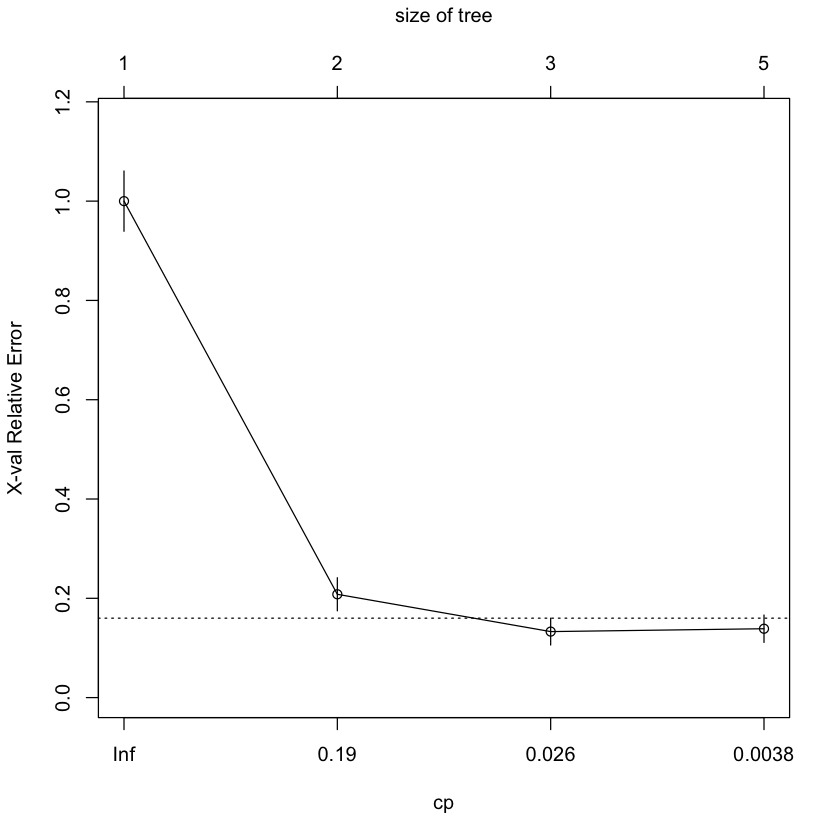

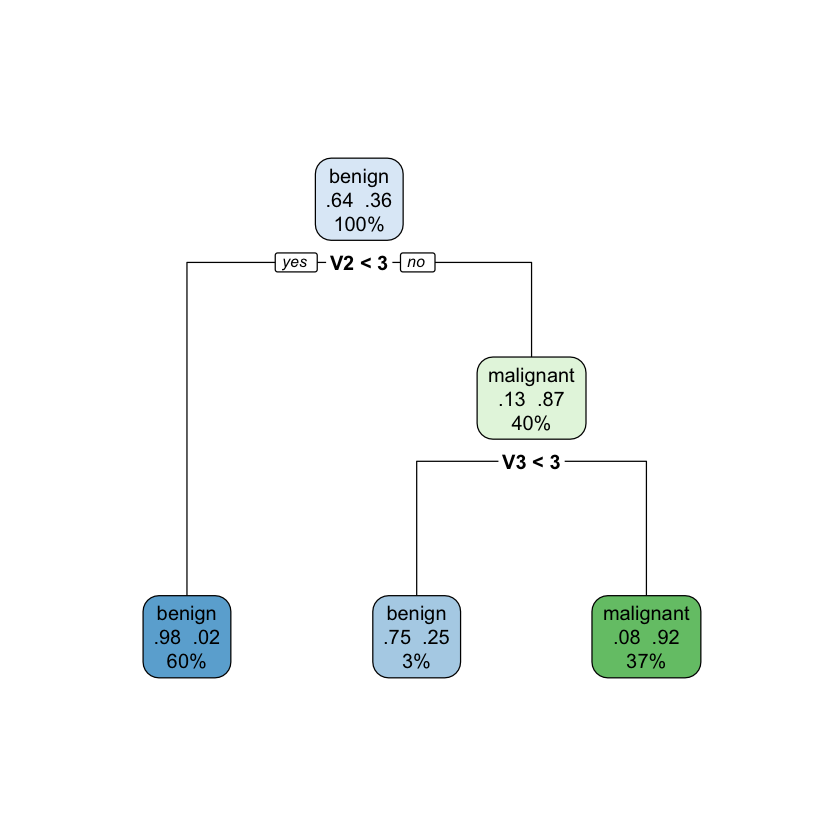

In [15]:
tree_p2_full <- rpart(
  class ~ .,
  data = train_p2,
  method = "class",
  parms = list(split = "gini"),
  control = rpart.control(cp = 0.001, xval = 10)
)

printcp(tree_p2_full)
plotcp(tree_p2_full)

cp_opt_p2 <- tree_p2_full$cptable[
  which.min(tree_p2_full$cptable[, "xerror"]),
  "CP"
]

cp_opt_p2

tree_p2_pruned <- prune(tree_p2_full, cp = cp_opt_p2)

printcp(tree_p2_pruned)

rpart.plot(
  tree_p2_pruned,
  type = 2,
  extra = 104,
  fallen.leaves = TRUE
)

In [16]:
primera_variable_p2 <- tree_p2_pruned$frame$var[1]
primera_variable_p2

descripcion_primera_p2 <- variable_labels_biopsy[primera_variable_p2]
descripcion_primera_p2

if (primera_variable_p2 == "<leaf>") {
  cat(
    paste0(
      "Comentario 2.b:\n",
      "Con el cp seleccionado, el árbol podado quedó reducido a una hoja y no presenta particiones internas.\n",
      "En ese caso, no existe una primera variable de partición que interpretar clínicamente.\n",
      "Esto indicaría que la poda fue demasiado estricta para conservar divisiones del árbol.\n"
    )
  )
} else {
  cat(
    paste0(
      "Comentario 2.b:\n",
      "Nosotros seleccionamos cp = ", round(cp_opt_p2, 6), " porque minimiza el xerror en la tabla de complejidad.\n",
      "Luego, en el árbol podado, la primera partición utiliza la variable ",
      primera_variable_p2, " (", descripcion_primera_p2, ").\n",
      "Esta variable es la primera porque genera la mayor reducción inicial de impureza entre biopsias benignas y malignas.\n",
      "Clínicamente, interpretamos que ", descripcion_primera_p2, " es una característica citológica relevante para separar el diagnóstico.\n",
      "Si valores altos de esta variable se dirigen hacia nodos con mayor proporción de casos malignos, entonces funciona como un indicador ",
      "de mayor sospecha diagnóstica.\n"
    )
  )
}

[1] "V2"

V2 
"Uniformity of cell size"

Comentario 2.b:
Nosotros seleccionamos cp = 0.014451 porque minimiza el xerror en la tabla de complejidad.
Luego, en el árbol podado, la primera partición utiliza la variable V2 (Uniformity of cell size).
Esta variable es la primera porque genera la mayor reducción inicial de impureza entre biopsias benignas y malignas.
Clínicamente, interpretamos que Uniformity of cell size es una característica citológica relevante para separar el diagnóstico.
Si valores altos de esta variable se dirigen hacia nodos con mayor proporción de casos malignos, entonces funciona como un indicador de mayor sospecha diagnóstica.


### Respuesta para 2.b

La interpretación se basa en el `cp` seleccionado y en el árbol podado impreso.  
Nosotros usamos el `cp` que minimiza el error de validación cruzada interna (`xerror`) y luego identificamos la primera variable de partición directamente desde el árbol podado. Esa primera variable es la que mejor separa inicialmente biopsias benignas y malignas.

## 2.c Random Forest e importancia de variables

Ajustamos un Random Forest con 500 árboles e identificamos las dos variables más relevantes según `MeanDecreaseGini`.


Call:
 randomForest(formula = class ~ ., data = train_p2, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 3

        OOB estimate of  error rate: 2.51%
Confusion matrix:
          benign malignant class.error
benign       298         7  0.02295082
malignant      5       168  0.02890173

Variable,MeanDecreaseGini,Descripcion
<chr>,<dbl>,<chr>
V2,60.88574,Uniformity of cell size
V3,47.50582,Uniformity of cell shape


Comentario 2.c:
Nosotros identificamos como variables más relevantes según MeanDecreaseGini a V2 (Uniformity of cell size), con MeanDecreaseGini = 60.8857, y V3 (Uniformity of cell shape), con MeanDecreaseGini = 47.5058.
Estas variables son las que más contribuyen a reducir la impureza de los nodos a lo largo de los árboles del Random Forest.


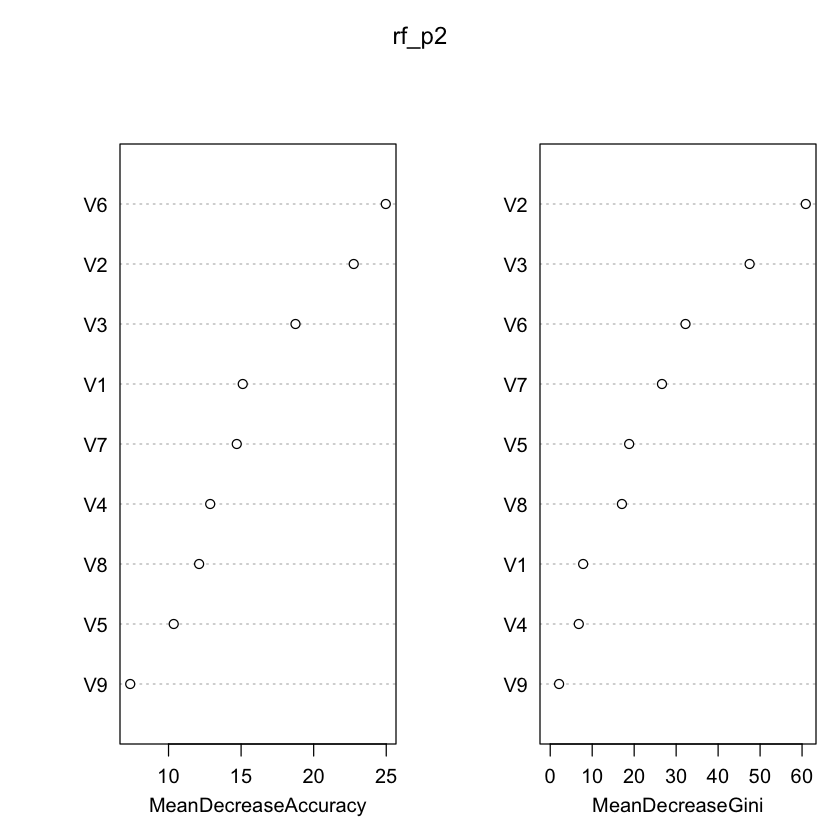

In [17]:
set.seed(123)

rf_p2 <- randomForest(
  class ~ .,
  data = train_p2,
  ntree = 500,
  importance = TRUE
)

rf_p2
varImpPlot(rf_p2)

imp_p2 <- importance(rf_p2, type = 2)

top2_gini_p2 <- imp_p2 %>%
  as.data.frame() %>%
  rownames_to_column("Variable") %>%
  arrange(desc(MeanDecreaseGini)) %>%
  slice(1:2) %>%
  mutate(Descripcion = variable_labels_biopsy[Variable])

top2_gini_p2

cat(
  paste0(
    "Comentario 2.c:\n",
    "Nosotros identificamos como variables más relevantes según MeanDecreaseGini a ",
    top2_gini_p2$Variable[1], " (", top2_gini_p2$Descripcion[1], "), con MeanDecreaseGini = ",
    round(top2_gini_p2$MeanDecreaseGini[1], 4), ", y ",
    top2_gini_p2$Variable[2], " (", top2_gini_p2$Descripcion[2], "), con MeanDecreaseGini = ",
    round(top2_gini_p2$MeanDecreaseGini[2], 4), ".\n",
    "Estas variables son las que más contribuyen a reducir la impureza de los nodos ",
    "a lo largo de los árboles del Random Forest.\n"
  )
)

### Respuesta para 2.c

Nosotros interpretamos `MeanDecreaseGini` como una medida de cuánto aporta cada variable a formar nodos más puros dentro del bosque. Las dos variables con mayor valor son las más relevantes para el diagnóstico según Random Forest.

## 2.d Evaluación comparativa

Comparamos Regresión Logística, Árbol podado y Random Forest sobre el conjunto de prueba.

In [18]:
prob_logit_p2 <- predict(mod_logit_p2, newdata = test_p2, type = "response")
prob_tree_p2 <- predict(tree_p2_pruned, newdata = test_p2, type = "prob")[, "malignant"]
prob_rf_p2 <- predict(rf_p2, newdata = test_p2, type = "prob")[, "malignant"]

eval_logit_p2 <- evaluar_clasificador(prob_logit_p2, test_p2$class, "malignant", "Regresión Logística")
eval_tree_p2  <- evaluar_clasificador(prob_tree_p2,  test_p2$class, "malignant", "Árbol podado")
eval_rf_p2    <- evaluar_clasificador(prob_rf_p2,    test_p2$class, "malignant", "Random Forest")

eval_logit_p2$cm$table
eval_tree_p2$cm$table
eval_rf_p2$cm$table

tabla_p2 <- bind_rows(
  eval_logit_p2$metricas,
  eval_tree_p2$metricas,
  eval_rf_p2$metricas
)

tabla_p2 %>%
  arrange(desc(AUC)) %>%
  kable(caption = "Problema 2: métricas en conjunto de prueba")

           Reference
Prediction  benign malignant
  benign       136         3
  malignant      3        63

           Reference
Prediction  benign malignant
  benign       133         7
  malignant      6        59

           Reference
Prediction  benign malignant
  benign       136         3
  malignant      3        63



Table: Problema 2: métricas en conjunto de prueba

|Modelo              | Accuracy| Sensibilidad| Especificidad| Precision|     F1| BalancedAccuracy|    AUC|
|:-------------------|--------:|------------:|-------------:|---------:|------:|----------------:|------:|
|Regresión Logística |   0.9707|       0.9545|        0.9784|    0.9545| 0.9545|           0.9665| 0.9962|
|Random Forest       |   0.9707|       0.9545|        0.9784|    0.9545| 0.9545|           0.9665| 0.9930|
|Árbol podado        |   0.9366|       0.8939|        0.9568|    0.9077| 0.9008|           0.9254| 0.9303|

In [19]:
mejor_auc_p2 <- tabla_p2 %>% arrange(desc(AUC)) %>% slice(1)
mejor_f1_p2 <- tabla_p2 %>% arrange(desc(F1)) %>% slice(1)
mejor_sens_p2 <- tabla_p2 %>% arrange(desc(Sensibilidad)) %>% slice(1)

mejor_auc_p2
mejor_f1_p2
mejor_sens_p2

rf_p2_metricas <- tabla_p2 %>% filter(Modelo == "Random Forest")
tree_p2_metricas <- tabla_p2 %>% filter(Modelo == "Árbol podado")
logit_p2_metricas <- tabla_p2 %>% filter(Modelo == "Regresión Logística")

rf_mejora_auc <- rf_p2_metricas$AUC > max(tree_p2_metricas$AUC, logit_p2_metricas$AUC)
rf_mejora_f1 <- rf_p2_metricas$F1 > max(tree_p2_metricas$F1, logit_p2_metricas$F1)
rf_mejora_sens <- rf_p2_metricas$Sensibilidad > max(tree_p2_metricas$Sensibilidad, logit_p2_metricas$Sensibilidad)

conclusion_rf_p2 <- ifelse(
  rf_mejora_auc & rf_mejora_f1 & rf_mejora_sens,
  "sí mejora sustancialmente porque supera simultáneamente AUC, F1-score y Sensibilidad",
  "no mejora sustancialmente en todas las dimensiones principales; su ventaja debe interpretarse con cautela"
)

cat(
  paste0(
    "Comentario 2.d:\n",
    "Regresión Logística obtuvo AUC = ", logit_p2_metricas$AUC, 
    ", F1 = ", logit_p2_metricas$F1, 
    " y Sensibilidad = ", logit_p2_metricas$Sensibilidad, ".\n",
    "Árbol podado obtuvo AUC = ", tree_p2_metricas$AUC, 
    ", F1 = ", tree_p2_metricas$F1, 
    " y Sensibilidad = ", tree_p2_metricas$Sensibilidad, ".\n",
    "Random Forest obtuvo AUC = ", rf_p2_metricas$AUC, 
    ", F1 = ", rf_p2_metricas$F1, 
    " y Sensibilidad = ", rf_p2_metricas$Sensibilidad, ".\n",
    "El mejor modelo por AUC es ", mejor_auc_p2$Modelo, "; por F1-score es ",
    mejor_f1_p2$Modelo, "; y por Sensibilidad es ", mejor_sens_p2$Modelo, ".\n",
    "Con estos resultados, nosotros concluimos que Random Forest ", conclusion_rf_p2, ".\n",
    "Dado que se trata de diagnóstico, damos especial peso a la Sensibilidad, porque interesa detectar correctamente casos malignos.\n"
  )
)

Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.9707,0.9545,0.9784,0.9545,0.9545,0.9665,0.9962


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.9707,0.9545,0.9784,0.9545,0.9545,0.9665,0.9962


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Regresión Logística,0.9707,0.9545,0.9784,0.9545,0.9545,0.9665,0.9962


Comentario 2.d:
Regresión Logística obtuvo AUC = 0.9962, F1 = 0.9545 y Sensibilidad = 0.9545.
Árbol podado obtuvo AUC = 0.9303, F1 = 0.9008 y Sensibilidad = 0.8939.
Random Forest obtuvo AUC = 0.993, F1 = 0.9545 y Sensibilidad = 0.9545.
El mejor modelo por AUC es Regresión Logística; por F1-score es Regresión Logística; y por Sensibilidad es Regresión Logística.
Con estos resultados, nosotros concluimos que Random Forest no mejora sustancialmente en todas las dimensiones principales; su ventaja debe interpretarse con cautela.
Dado que se trata de diagnóstico, damos especial peso a la Sensibilidad, porque interesa detectar correctamente casos malignos.


### Respuesta para 2.d

La respuesta se basa en la tabla comparativa y en el comentario anterior. Nosotros no asumimos que Random Forest mejora solo por ser más flexible; verificamos si supera al árbol individual y a la Regresión Logística en AUC, F1-score y Sensibilidad.

Si Random Forest no domina claramente esas métricas, concluimos que no hay una mejora sustancial general. En un problema de diagnóstico, la Sensibilidad tiene especial importancia porque representa la capacidad de detectar casos malignos.

# Problema 3 — Base `hacide`

La base `hacide` contiene los objetos `hacide.train` y `hacide.test`. En R se cargan con `data(hacide)`. La clase positiva y minoritaria es `cls = 1`.

## 3.a Proporciones de clase y Regresión Logística

In [20]:
data(hacide)

train_p3 <- hacide.train
test_p3  <- hacide.test

train_p3$cls <- factor(train_p3$cls, levels = c(0, 1))
test_p3$cls <- factor(test_p3$cls, levels = c(0, 1))

table(train_p3$cls)
prop.table(table(train_p3$cls))

table(test_p3$cls)
prop.table(table(test_p3$cls))

prop_min_train_p3 <- prop.table(table(train_p3$cls))["1"]
prop_min_test_p3 <- prop.table(table(test_p3$cls))["1"]

prop_min_train_p3
prop_min_test_p3

cat(
  paste0(
    "Comentario 3.a:\n",
    "Nosotros identificamos la clase minoritaria como cls = 1.\n",
    "En entrenamiento, la clase minoritaria representa el ",
    round(100 * prop_min_train_p3, 2), "% de las observaciones.\n",
    "En prueba, representa el ", round(100 * prop_min_test_p3, 2), "% de las observaciones.\n",
    "Como esta proporción es baja, Accuracy será poco informativa: un modelo podría clasificar casi todo ",
    "como clase 0 y aun así obtener una Accuracy alta.\n"
  )
)

mod_logit_p3 <- glm(
  cls ~ x1 + x2,
  data = train_p3,
  family = binomial(link = "logit")
)

summary(mod_logit_p3)


  0   1 
980  20 


   0    1 
0.98 0.02 


  0   1 
245   5 


   0    1 
0.98 0.02 

1 
0.02

1 
0.02

Comentario 3.a:
Nosotros identificamos la clase minoritaria como cls = 1.
En entrenamiento, la clase minoritaria representa el 2% de las observaciones.
En prueba, representa el 2% de las observaciones.
Como esta proporción es baja, Accuracy será poco informativa: un modelo podría clasificar casi todo como clase 0 y aun así obtener una Accuracy alta.



Call:
glm(formula = cls ~ x1 + x2, family = binomial(link = "logit"), 
    data = train_p3)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -6.0046     0.5903 -10.172  < 2e-16 ***
x1           -1.6424     0.3544  -4.635 3.57e-06 ***
x2           -1.5961     0.3080  -5.182 2.20e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 196.08  on 999  degrees of freedom
Residual deviance: 118.20  on 997  degrees of freedom
AIC: 124.2

Number of Fisher Scoring iterations: 8


### Respuesta para 3.a

Nosotros reportamos la proporción de `cls = 1` porque es la clase minoritaria. El porcentaje exacto queda impreso en la celda anterior para entrenamiento y prueba. Debido al desbalance, la Accuracy puede ser engañosa: un modelo que prediga casi siempre la clase mayoritaria puede obtener alta Accuracy y, aun así, fallar en detectar la clase relevante.

## 3.b LDA, QDA y Naive Bayes

In [21]:
mod_lda_p3 <- MASS::lda(
  cls ~ x1 + x2,
  data = train_p3
)

mod_qda_p3 <- MASS::qda(
  cls ~ x1 + x2,
  data = train_p3
)

mod_nb_p3 <- e1071::naiveBayes(
  cls ~ x1 + x2,
  data = train_p3
)

mod_lda_p3
mod_qda_p3
mod_nb_p3

cat(
  paste0(
    "Comentario 3.b:\n",
    "Nosotros ajustamos LDA, QDA y Naive Bayes con los mismos predictores x1 y x2.\n",
    "LDA usa una matriz de covarianzas común, QDA permite matrices distintas por clase ",
    "y Naive Bayes asume independencia condicional entre x1 y x2 dado cls.\n"
  )
)

Call:
lda(cls ~ x1 + x2, data = train_p3)

Prior probabilities of groups:
   0    1 
0.98 0.02 

Group means:
           x1          x2
0 -0.01273371 -0.03240901
1 -0.96859857 -1.71371468

Coefficients of linear discriminants:
         LD1
x1 -1.261710
x2 -0.651837

Call:
qda(cls ~ x1 + x2, data = train_p3)

Prior probabilities of groups:
   0    1 
0.98 0.02 

Group means:
           x1          x2
0 -0.01273371 -0.03240901
1 -0.96859857 -1.71371468


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
   0    1 
0.98 0.02 

Conditional probabilities:
   x1
Y          [,1]     [,2]
  0 -0.01273371 0.527709
  1 -0.96859857 1.677673

   x2
Y          [,1]      [,2]
  0 -0.03240901 1.0594063
  1 -1.71371468 0.7503571


Comentario 3.b:
Nosotros ajustamos LDA, QDA y Naive Bayes con los mismos predictores x1 y x2.
LDA usa una matriz de covarianzas común, QDA permite matrices distintas por clase y Naive Bayes asume independencia condicional entre x1 y x2 dado cls.


## 3.c Árbol de Decisión y Random Forest


Call:
 randomForest(formula = cls ~ x1 + x2, data = train_p3, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 1

        OOB estimate of  error rate: 1.2%
Confusion matrix:
    0  1 class.error
0 977  3 0.003061224
1   9 11 0.450000000

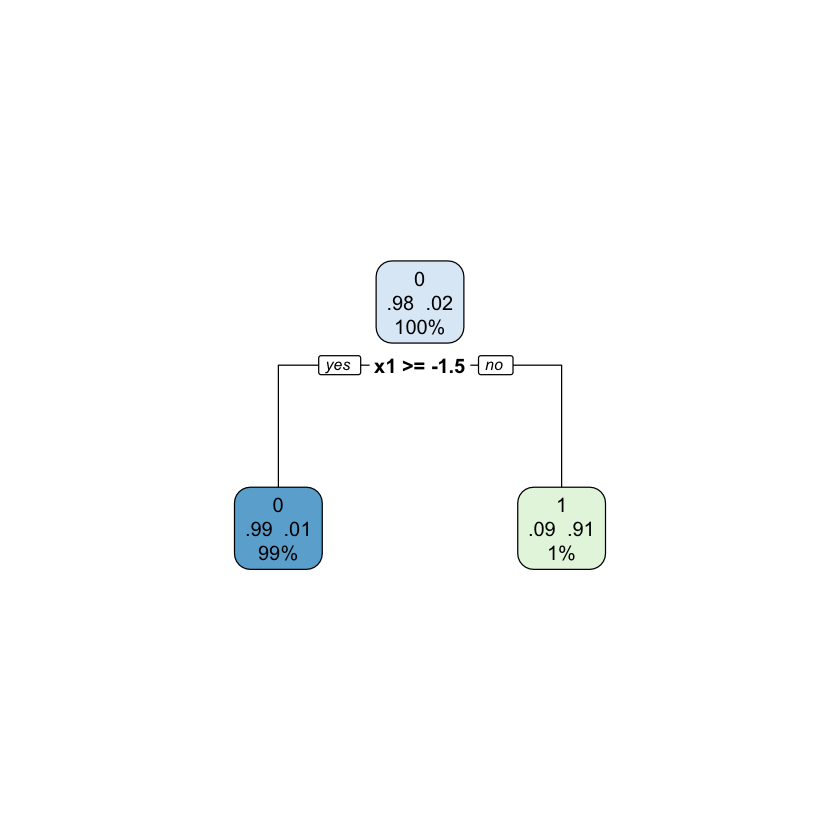

Comentario 3.c:
Nosotros ajustamos un árbol individual y un Random Forest con los predictores x1 y x2.
El árbol individual permite reglas interpretables, mientras que Random Forest busca mayor estabilidad al combinar múltiples árboles.


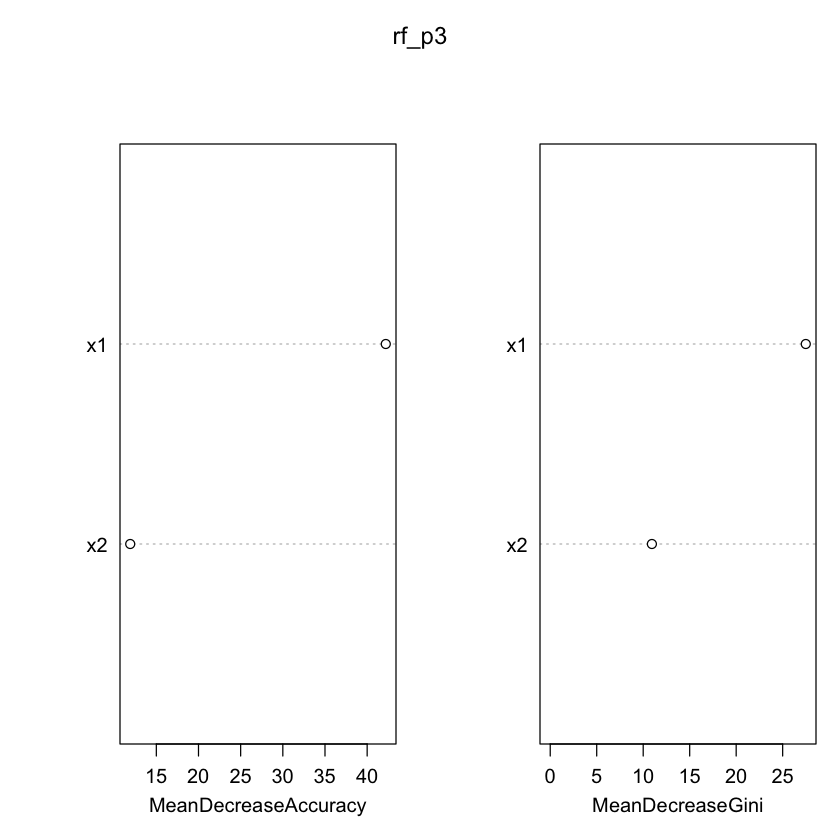

In [22]:
tree_p3 <- rpart(
  cls ~ x1 + x2,
  data = train_p3,
  method = "class",
  parms = list(split = "gini")
)

rpart.plot(
  tree_p3,
  type = 2,
  extra = 104,
  fallen.leaves = TRUE
)

set.seed(123)

rf_p3 <- randomForest(
  cls ~ x1 + x2,
  data = train_p3,
  ntree = 500,
  importance = TRUE
)

rf_p3
varImpPlot(rf_p3)

cat(
  paste0(
    "Comentario 3.c:\n",
    "Nosotros ajustamos un árbol individual y un Random Forest con los predictores x1 y x2.\n",
    "El árbol individual permite reglas interpretables, mientras que Random Forest busca mayor estabilidad ",
    "al combinar múltiples árboles.\n"
  )
)

## 3.d Evaluación de los seis clasificadores

Evaluamos Regresión Logística, LDA, QDA, Naive Bayes, Árbol de Decisión y Random Forest sobre `hacide.test` con punto de corte 0.5.

In [23]:
prob_logit_p3 <- predict(mod_logit_p3, newdata = test_p3, type = "response")

pred_lda_p3 <- predict(mod_lda_p3, newdata = test_p3)
prob_lda_p3 <- pred_lda_p3$posterior[, "1"]

pred_qda_p3 <- predict(mod_qda_p3, newdata = test_p3)
prob_qda_p3 <- pred_qda_p3$posterior[, "1"]

prob_nb_p3 <- predict(mod_nb_p3, newdata = test_p3, type = "raw")[, "1"]

prob_tree_p3 <- predict(tree_p3, newdata = test_p3, type = "prob")[, "1"]

prob_rf_p3 <- predict(rf_p3, newdata = test_p3, type = "prob")[, "1"]

eval_logit_p3 <- evaluar_clasificador(prob_logit_p3, test_p3$cls, "1", "Regresión Logística")
eval_lda_p3   <- evaluar_clasificador(prob_lda_p3,   test_p3$cls, "1", "LDA")
eval_qda_p3   <- evaluar_clasificador(prob_qda_p3,   test_p3$cls, "1", "QDA")
eval_nb_p3    <- evaluar_clasificador(prob_nb_p3,    test_p3$cls, "1", "Naive Bayes")
eval_tree_p3  <- evaluar_clasificador(prob_tree_p3,  test_p3$cls, "1", "Árbol de Decisión")
eval_rf_p3    <- evaluar_clasificador(prob_rf_p3,    test_p3$cls, "1", "Random Forest")

eval_logit_p3$cm$table
eval_lda_p3$cm$table
eval_qda_p3$cm$table
eval_nb_p3$cm$table
eval_tree_p3$cm$table
eval_rf_p3$cm$table

tabla_p3 <- bind_rows(
  eval_logit_p3$metricas,
  eval_lda_p3$metricas,
  eval_qda_p3$metricas,
  eval_nb_p3$metricas,
  eval_tree_p3$metricas,
  eval_rf_p3$metricas
)

tabla_p3 %>%
  arrange(desc(BalancedAccuracy)) %>%
  kable(caption = "Problema 3: métricas en conjunto de prueba")

          Reference
Prediction   0   1
         0 245   5
         1   0   0

          Reference
Prediction   0   1
         0 245   3
         1   0   2

          Reference
Prediction   0   1
         0 245   3
         1   0   2

          Reference
Prediction   0   1
         0 245   3
         1   0   2

          Reference
Prediction   0   1
         0 245   4
         1   0   1

          Reference
Prediction   0   1
         0 245   3
         1   0   2



Table: Problema 3: métricas en conjunto de prueba

|Modelo              | Accuracy| Sensibilidad| Especificidad| Precision|     F1| BalancedAccuracy|    AUC|
|:-------------------|--------:|------------:|-------------:|---------:|------:|----------------:|------:|
|LDA                 |    0.988|          0.4|             1|         1| 0.5714|              0.7| 0.7298|
|QDA                 |    0.988|          0.4|             1|         1| 0.5714|              0.7| 0.9902|
|Naive Bayes         |    0.988|          0.4|             1|         1| 0.5714|              0.7| 0.9902|
|Random Forest       |    0.988|          0.4|             1|         1| 0.5714|              0.7| 0.8865|
|Árbol de Decisión   |    0.984|          0.2|             1|         1| 0.3333|              0.6| 0.6000|
|Regresión Logística |    0.980|          0.0|             1|       NaN| 0.0000|              0.5| 0.8041|

In [24]:
mejor_balance_p3 <- tabla_p3 %>% arrange(desc(BalancedAccuracy)) %>% slice(1)
mejor_f1_p3 <- tabla_p3 %>% arrange(desc(F1)) %>% slice(1)
mejor_auc_p3 <- tabla_p3 %>% arrange(desc(AUC)) %>% slice(1)

mejor_balance_p3
mejor_f1_p3
mejor_auc_p3

cat(
  paste0(
    "Comentario 3.d:\n",
    "Nosotros usamos BalancedAccuracy para identificar el mejor equilibrio entre Sensibilidad y Especificidad.\n",
    "El modelo con mayor BalancedAccuracy es ", mejor_balance_p3$Modelo,
    ", con BalancedAccuracy = ", mejor_balance_p3$BalancedAccuracy,
    ", Sensibilidad = ", mejor_balance_p3$Sensibilidad,
    " y Especificidad = ", mejor_balance_p3$Especificidad, ".\n",
    "El mejor modelo por F1-score es ", mejor_f1_p3$Modelo, " con F1 = ", mejor_f1_p3$F1, ".\n",
    "El mejor modelo por AUC es ", mejor_auc_p3$Modelo, " con AUC = ", mejor_auc_p3$AUC, ".\n",
    "En este problema, Accuracy no debe usarse sola porque la clase 1 es minoritaria.\n"
  )
)

Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LDA,0.988,0.4,1,1,0.5714,0.7,0.7298


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LDA,0.988,0.4,1,1,0.5714,0.7,0.7298


Modelo,Accuracy,Sensibilidad,Especificidad,Precision,F1,BalancedAccuracy,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
QDA,0.988,0.4,1,1,0.5714,0.7,0.9902


Comentario 3.d:
Nosotros usamos BalancedAccuracy para identificar el mejor equilibrio entre Sensibilidad y Especificidad.
El modelo con mayor BalancedAccuracy es LDA, con BalancedAccuracy = 0.7, Sensibilidad = 0.4 y Especificidad = 1.
El mejor modelo por F1-score es LDA con F1 = 0.5714.
El mejor modelo por AUC es QDA con AUC = 0.9902.
En este problema, Accuracy no debe usarse sola porque la clase 1 es minoritaria.


### Respuesta para 3.d

La tabla comparativa responde el enunciado. Nosotros consideramos que Accuracy es poco informativa porque `cls = 1` es minoritaria: un modelo podría clasificar casi todo como `0` y obtener alta Accuracy sin detectar adecuadamente la clase relevante.

Por eso usamos `BalancedAccuracy` para identificar el mejor equilibrio entre Sensibilidad y Especificidad. El modelo con mayor `BalancedAccuracy`, impreso en el comentario anterior, es nuestra elección para el mejor balance entre ambas métricas. F1-score y AUC se usan como criterios complementarios.

## Estrategia para mitigar el desbalance

Nosotros proponemos ajustar el punto de corte mediante el índice de Youden:

$$
J = Sensibilidad + Especificidad - 1
$$

Esta estrategia es adecuada porque el problema no es solo clasificar correctamente la mayoría, sino mejorar el equilibrio entre detectar la clase minoritaria y no deteriorar demasiado la especificidad. También podrían usarse sobremuestreo, submuestreo o ROSE para balancear la muestra.

In [25]:
roc_rf_p3 <- pROC::roc(
  response = as.numeric(test_p3$cls == "1"),
  predictor = prob_rf_p3,
  quiet = TRUE
)

youden_rf_p3 <- pROC::coords(
  roc_rf_p3,
  x = "best",
  best.method = "youden",
  ret = c("threshold", "sensitivity", "specificity")
)

youden_rf_p3

cat(
  paste0(
    "Comentario sobre punto de corte:\n",
    "Para Random Forest, el umbral sugerido por Youden es ",
    round(as.numeric(youden_rf_p3["threshold"]), 4), ".\n",
    "Con ese umbral se obtiene Sensibilidad = ",
    round(as.numeric(youden_rf_p3["sensitivity"]), 4),
    " y Especificidad = ",
    round(as.numeric(youden_rf_p3["specificity"]), 4), ".\n",
    "Este umbral podría usarse en lugar de 0.5 para mejorar el equilibrio entre ambas métricas ",
    "cuando las clases están desbalanceadas.\n"
  )
)

threshold,sensitivity,specificity
<dbl>,<dbl>,<dbl>
0.025,0.8,0.9795918


Comentario sobre punto de corte:
Para Random Forest, el umbral sugerido por Youden es 0.025.
Con ese umbral se obtiene Sensibilidad = 0.8 y Especificidad = 0.9796.
Este umbral podría usarse en lugar de 0.5 para mejorar el equilibrio entre ambas métricas cuando las clases están desbalanceadas.


# Conclusión general

Nosotros aplicamos y comparamos modelos supervisados usando entrenamiento/prueba, métricas de clasificación, análisis de supuestos e interpretación de resultados.

La elección final de un modelo no debe depender solo de Accuracy. Debe considerar el tipo de problema, el desbalance de clases, la interpretabilidad y métricas como Sensibilidad, Especificidad, F1-score, Balanced Accuracy y AUC.